In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('/content/Titanic-Dataset.csv.xls')
df.sample(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
793,794,0,1,"Hoyt, Mr. William Fisher",male,NaN,0,0,PC 17600,30.6958,NaN,C
25,26,1,3,"Asplund, Mrs. Carl Oscar (Selma Augusta Emilia...",female,38.0,1,5,347077,31.3875,NaN,S
405,406,0,2,"Gale, Mr. Shadrach",male,34.0,1,0,28664,21.0000,NaN,S
618,619,1,2,"Becker, Miss. Marion Louise",female,4.0,2,1,230136,39.0000,F4,S
134,135,0,2,"Sobey, Mr. Samuel James Hayden",male,25.0,0,0,C.A. 29178,13.0000,NaN,S
256,257,1,1,"Thorne, Mrs. Gertrude Maybelle",female,NaN,0,0,PC 17585,79.2000,NaN,C
639,640,0,3,"Thorneycroft, Mr. Percival",male,NaN,1,0,376564,16.1000,NaN,S
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
148,149,0,2,"Navratil, Mr. Michel (""Louis M Hoffman"")",male,36.5,0,2,230080,26.0000,F2,S
885,886,0,3,"Rice, Mrs. William (Margaret Norton)",female,39.0,0,5,382652,29.1250,NaN,Q


In [3]:
df.shape

(891, 12)

In [4]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [5]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [7]:
X = df.drop(columns=['Survived','PassengerId'])
y = df['Survived']

feature engineering


In [8]:
X['Pclass'].value_counts()

,count
Pclass,
3,491
1,216
2,184


In [9]:
df.groupby('Pclass')['Survived'].mean()

,Survived
Pclass,
1,0.629630
2,0.472826
3,0.242363


<Axes: xlabel='Pclass', ylabel='count'>

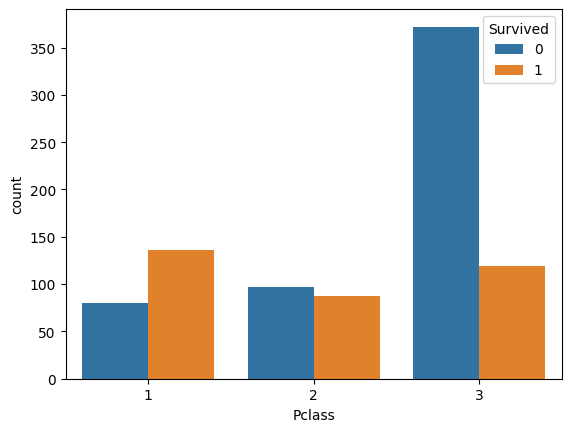

In [10]:
sns.countplot(x='Pclass', hue='Survived', data=df)

The plot clearly shows that passenger class had a major impact on survival in the Titanic dataset.
1st class passengers had the highest chance of survival
2nd class passengers had moderate survival chances
3rd class passengers had the lowest survival rate, with most deaths
This indicates a strong relationship between socioeconomic status and survival probability.

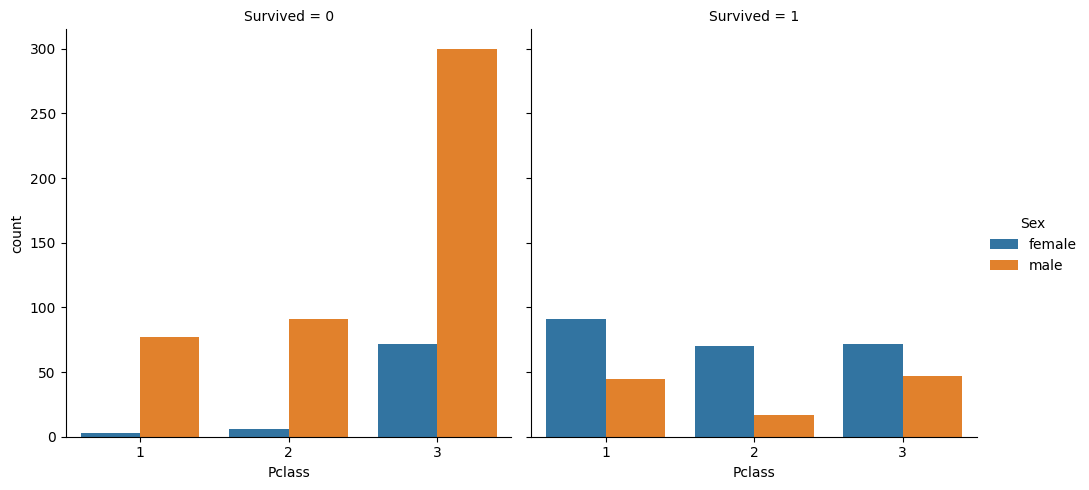

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.catplot(x='Pclass', hue='Sex', col='Survived',
            data=df, kind='count')

plt.show()

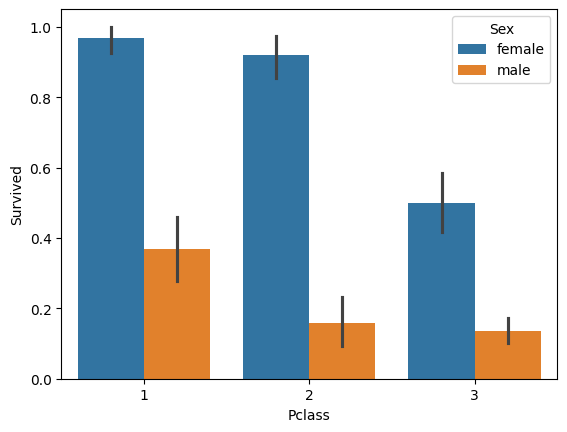

In [12]:
sns.barplot(x='Pclass', y='Survived', hue='Sex', data=df)
plt.show()

In [13]:
df.groupby('Pclass')['Sex'].value_counts()

Pclass  Sex   
1       male      122
        female     94
2       male      108
        female     76
3       male      347
        female    144
Name: count, dtype: int64

<Axes: xlabel='Pclass', ylabel='count'>

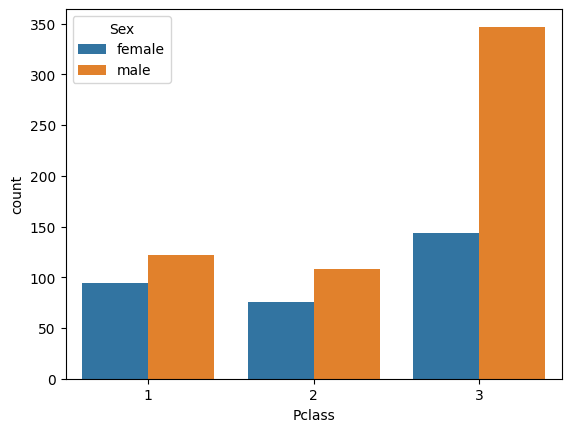

In [14]:
sns.countplot(df, x='Pclass', hue='Sex')

In [15]:
df[df["Survived"]==1].groupby('Pclass')['Sex'].value_counts()

Pclass  Sex   
1       female    91
        male      45
2       female    70
        male      17
3       female    72
        male      47
Name: count, dtype: int64

<Axes: xlabel='Pclass', ylabel='count'>

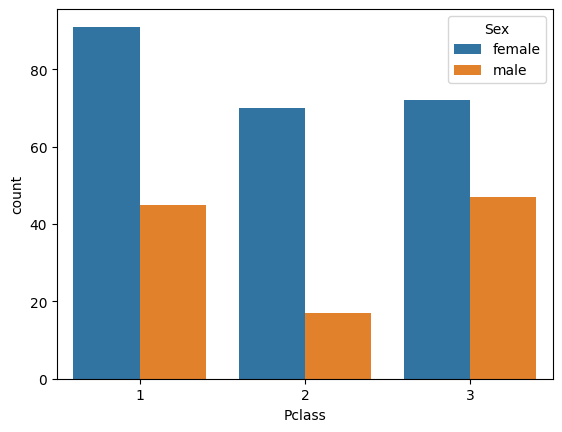

In [16]:
sns.countplot(df[df["Survived"]==1],x = 'Pclass',hue = 'Sex')

there were total 94 female and 122 male and 94 female in class 1 out of which 91 female survived and only 45 male survived that could happen bcz initially female were resqued

class 2:
out of 76 female passenger 70 got survied

class 3:
out of 144 female passenger 72 got survived

<Axes: xlabel='Pclass', ylabel='count'>

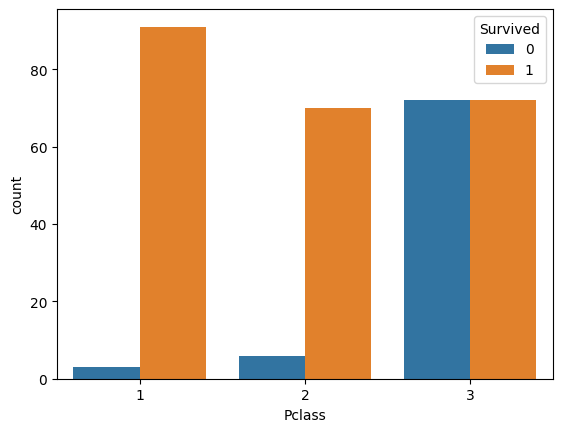

In [17]:
sns.countplot(df[df['Sex']=='female'],x = 'Pclass',hue = 'Survived')

In [18]:
(len(df[(df['Pclass']==1)&(df['Sex']=='female')&(df['Survived']==1)])/len(df[(df['Pclass']==1)&(df['Sex']=='female')]))*100

96.80851063829788

In [19]:
(len(df[(df['Pclass']==1)&(df['Sex']=='male')&(df['Survived']==1)])/len(df[(df['Pclass']==1)&(df['Sex']=='male')]))*100


36.885245901639344

In [20]:
(len(df[(df['Pclass']==2)&(df['Sex']=='female')&(df['Survived']==1)])/len(df[(df['Pclass']==2)&(df['Sex']=='female')]))*100


92.10526315789474

In [21]:
(len(df[(df['Pclass']==2)&(df['Sex']=='male')&(df['Survived']==1)])/len(df[(df['Pclass']==2)&(df['Sex']=='male')]))*100


15.74074074074074

In [22]:
(len(df[(df['Pclass']==3)&(df['Sex']=='female')&(df['Survived']==1)])/len(df[(df['Pclass']==3)&(df['Sex']=='female')]))*100


50.0

In [23]:
(len(df[(df['Pclass']==3)&(df['Sex']=='male')&(df['Survived']==1)])/len(df[(df['Pclass']==3)&(df['Sex']=='male')]))*100


13.544668587896252

<Axes: xlabel='Pclass', ylabel='count'>

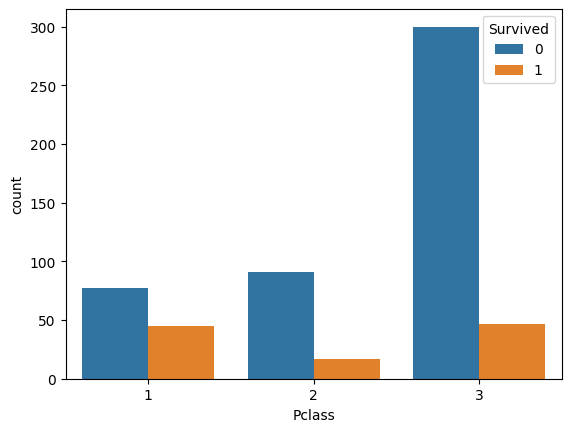

In [24]:
sns.countplot(df[df['Sex']=='male'],x = 'Pclass',hue = 'Survived')


for feature AGE

<Axes: xlabel='Age', ylabel='Count'>

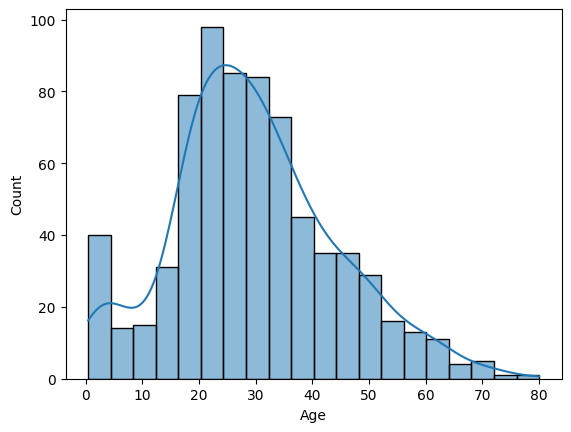

In [25]:
sns.histplot(df,x ='Age',kde = True)

In [26]:
print(f'number of minors = {len(df[df['Age']<18])}\nnumbers of adult = {len(df[(df['Age']<=60)&(df['Age']>=18)])}\nnumbers of senior citizen = {len(df[df['Age']>60])}')

number of minors = 113
numbers of adult = 579
numbers of senior citizen = 22


In [27]:
minor = len(df[df['Age']<18])
adult = len(df[(df['Age']<=60)&(df['Age']>=18)])
senior = len(df[df['Age']>60])

<Axes: xlabel='Sex', ylabel='count'>

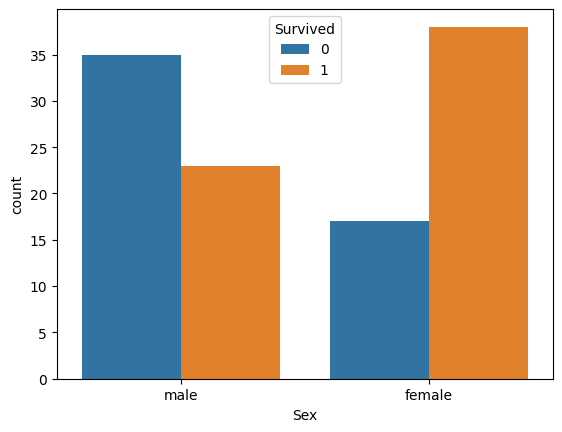

In [28]:
sns.countplot(df[df['Age']<18],x = 'Sex',hue = 'Survived')

In [29]:
(len(df[(df['Sex']=='female')&(df['Age']<18)&(df['Survived']==1)])/len(df[(df['Sex']=='female')&(df['Age']<18)]))*100

69.0909090909091

In [30]:
(len(df[(df['Sex']=='male')&(df['Age']<18)&(df['Survived']==1)])/len(df[(df['Sex']=='male')&(df['Age']<18)]))*100


39.6551724137931

<Axes: xlabel='Sex', ylabel='count'>

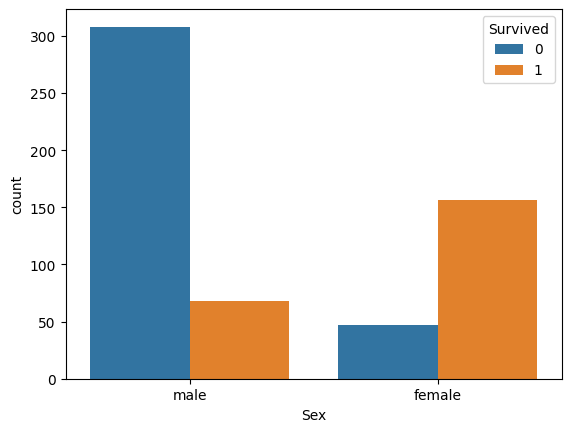

In [31]:
sns.countplot(df[(df['Age']<=60)&(df['Age']>=18)],x = 'Sex',hue = 'Survived')

In [32]:
(len(df[(df['Sex']=='female') & (df['Age']<=60) & (df['Age']>=18) & (df['Survived']==1)]) / len(df[(df['Sex']=='female') & (df['Age']<=60) & (df['Age']>=18)])) * 100

76.84729064039408

In [33]:
(len(df[(df['Sex']=='male') & (df['Age']<=60) & (df['Age']>=18) & (df['Survived']==1)]) / len(df[(df['Sex']=='male') & (df['Age']<=60) & (df['Age']>=18)])) * 100


18.085106382978726

<Axes: xlabel='Sex', ylabel='count'>

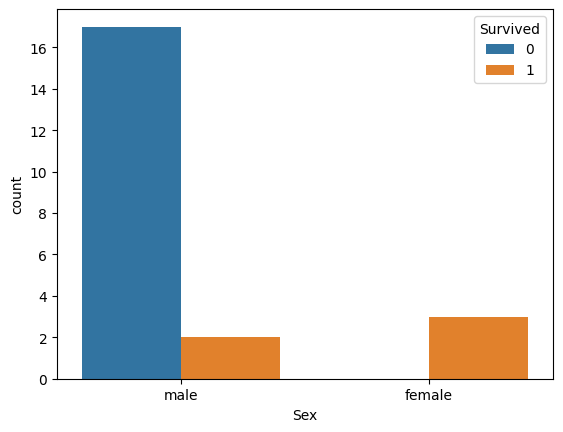

In [34]:
sns.countplot(df[df['Age']>60],x = 'Sex',hue = 'Survived')

In [35]:
(len(df[(df['Sex']=='female')&(df['Age']>60)&(df['Survived']==1)])/len(df[(df['Sex']=='female')&(df['Age']>60)]))*100


100.0

In [36]:
(len(df[(df['Sex']=='male')&(df['Age']>60)&(df['Survived']==1)])/len(df[(df['Sex']=='male')&(df['Age']>60)]))*100


10.526315789473683

In [37]:
len(df[(df['Sex']=='male')&(df['Age']>60)])

19

In [38]:
df['Age_group'] = pd.cut(
    df['Age'],
    bins=[0, 17, 60, 100],
    labels=['minor', 'adult', 'senior']
)

In [39]:
df['Age_group'].value_counts()

,count
Age_group,
adult,579
minor,113
senior,22


In [40]:
df.loc[df['Age'].isna(), 'Pclass'].value_counts()

,count
Pclass,
3,136
1,30
2,11


In [41]:
len(df[df['Pclass']==1])

216

In [42]:
(len(df[(df['Age'].isna())&(df['Pclass']==1)])/len(df[df['Pclass']==1]))*100

13.88888888888889

In [43]:
(len(df[(df['Age'].isna())&(df['Pclass']==2)])/len(df[df['Pclass']==2]))*100

5.978260869565218

In [44]:
(len(df[(df['Age'].isna())&(df['Pclass']==3)])/len(df[df['Pclass']==3]))*100


27.698574338085542

In [45]:
df['missing_age'] = df['Age'].isna().astype(int)

In [46]:
df['missing_age'].value_counts()

,count
missing_age,
0,714
1,177


In [47]:
df['Age'] = df['Age'].fillna(df['Age'].median())

In [48]:
df['Sex'].value_counts()

,count
Sex,
male,577
female,314


In [49]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked', 'Age_group',
       'missing_age'],
      dtype='object')

In [50]:
df['Cabin'].value_counts()


,count
Cabin,
G6,4
C23 C25 C27,4
B96 B98,4
F2,3
D,3
...,...
E17,1
A24,1
C50,1


In [51]:
df['Cabin'].isnull().sum()

np.int64(687)

In [52]:
df['has_cabin'] = df['Cabin'].notnull().astype(int)
df['has_cabin'].value_counts()

,count
has_cabin,
0,687
1,204


<Axes: xlabel='has_cabin', ylabel='count'>

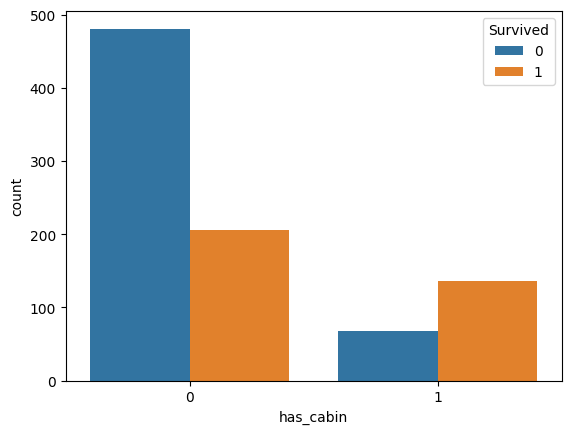

In [53]:
sns.countplot(df,x = 'has_cabin',hue = 'Survived')

In [54]:
len(df[(df['has_cabin']==1)&(df['Survived']==1)])/len(df[df['Survived']==1])

0.39766081871345027

In [55]:
len(df[df['Survived']==1])/len(df)

0.3838383838383838

In [56]:
len(df[df['has_cabin']==1])/len(df)

0.22895622895622897

In [57]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked', 'Age_group',
       'missing_age', 'has_cabin'],
      dtype='object')

In [58]:
df['Embarked'].value_counts()

,count
Embarked,
S,644
C,168
Q,77


<Axes: xlabel='Embarked', ylabel='count'>

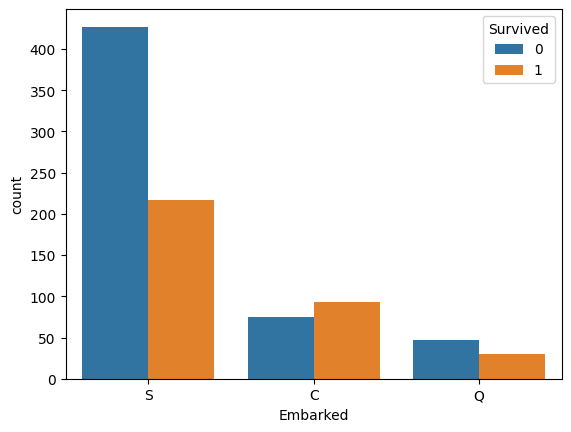

In [59]:
sns.countplot(df,x = 'Embarked',hue = 'Survived')

In [60]:
(len(df[(df['Embarked']=='S')&(df['Survived']==1)])/len(df[df['Embarked']=='S']))*100

33.69565217391305

In [61]:
(len(df[(df['Embarked']=='C')&(df['Survived']==1)])/len(df[df['Embarked']=='C']))*100

55.35714285714286

In [62]:
(len(df[(df['Embarked']=='Q')&(df['Survived']==1)])/len(df[df['Embarked']=='Q']))*100

38.961038961038966

In [63]:
df.groupby(['Embarked', 'Pclass'])['Survived'].mean()


Embarked  Pclass
C         1         0.694118
          2         0.529412
          3         0.378788
Q         1         0.500000
          2         0.666667
          3         0.375000
S         1         0.582677
          2         0.463415
          3         0.189802
Name: Survived, dtype: float64

In [64]:
df.groupby(['Embarked','Pclass'])['Fare'].mean()

Embarked  Pclass
C         1         104.718529
          2          25.358335
          3          11.214083
Q         1          90.000000
          2          12.350000
          3          11.183393
S         1          70.364862
          2          20.327439
          3          14.644083
Name: Fare, dtype: float64

In [65]:
df.groupby('Embarked')['Sex'].value_counts()

Embarked  Sex   
C         male       95
          female     73
Q         male       41
          female     36
S         male      441
          female    203
Name: count, dtype: int64

In [66]:
df.groupby('Embarked')['Sex'].value_counts()


Embarked  Sex   
C         male       95
          female     73
Q         male       41
          female     36
S         male      441
          female    203
Name: count, dtype: int64

In [67]:
pd.crosstab(df['Embarked'], df['Pclass'], normalize='index')

Pclass,1,2,3
Embarked,,,
C,0.505952,0.101190,0.392857
Q,0.025974,0.038961,0.935065
S,0.197205,0.254658,0.548137


55% of passenger who have embarked from "s" has survived
they have paid a high amount as fare with respect to others this could be a reason of there survival

In [68]:
df.groupby(['Pclass','has_cabin','Sex'])['Fare'].mean()

Pclass  has_cabin  Sex   
1       0          female    137.680769
                   male       47.559100
        1          female    101.061420
                   male       72.815703
2       0          female     23.084659
                   male       19.502328
        1          female     14.614170
                   male       23.812500
3       0          female     16.173553
                   male       12.734198
        1          female     14.859717
                   male        8.537500
Name: Fare, dtype: float64

female who has cabin has paid more fare then man

In [69]:
df.groupby(['Pclass','has_cabin','Sex'])['Survived'].value_counts()


Pclass  has_cabin  Sex     Survived
1       0          female  1            13
                   male    0            21
                           1             6
        1          female  1            78
                           0             3
                   male    0            56
                           1            39
2       0          female  1            61
                           0             5
                   male    0            89
                           1            13
        1          female  1             9
                           0             1
                   male    1             4
                           0             2
3       0          female  0            70
                           1            68
                   male    0           296
                           1            45
        1          female  1             4
                           0             2
                   male    0             4
                           1             2
Name: count, dtype: int64

In [70]:
df['cabin_female'] = ((df['Sex']=='female')&(df['has_cabin']==1)).astype(int)

In [71]:
df['cabin_female'].value_counts()

,count
cabin_female,
0,794
1,97


In [72]:
df['Ticket'].sample(10)

,Ticket
452,113051
378,2648
662,5727
440,F.C.C. 13529
508,C 4001
535,F.C.C. 13529
329,111361
200,345770
144,231945
728,236853


In [73]:
df['ticket_count'] = df.groupby('Ticket')['Ticket'].transform('count')

In [74]:
df['fare_per_person'] = df['Fare'] / df['ticket_count']


<Axes: xlabel='ticket_count', ylabel='count'>

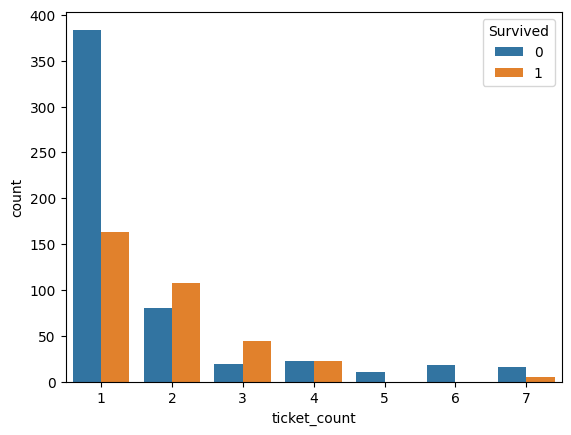

In [75]:
sns.countplot(df,x='ticket_count',hue='Survived')

<Axes: xlabel='fare_per_person', ylabel='Count'>

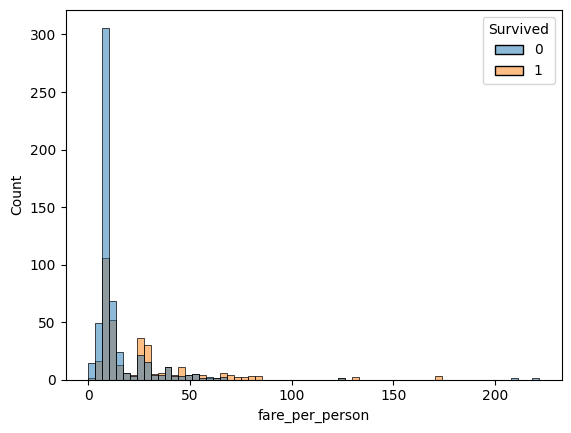

In [76]:
sns.histplot(df,x='fare_per_person',hue='Survived')

passenger who had paid more price had grater chances of survival

In [77]:
df['ticket_count'].dtype

dtype('int64')

In [78]:
df['sm_group'] = ((df['ticket_count']==2)|(df['ticket_count']==3)).astype(int)

In [79]:
df['sm_group'].value_counts()

,count
sm_group,
0,640
1,251


In [80]:
df['SibSp'].value_counts()

,count
SibSp,
0,608
1,209
2,28
4,18
3,16
8,7
5,5


<Axes: xlabel='SibSp', ylabel='count'>

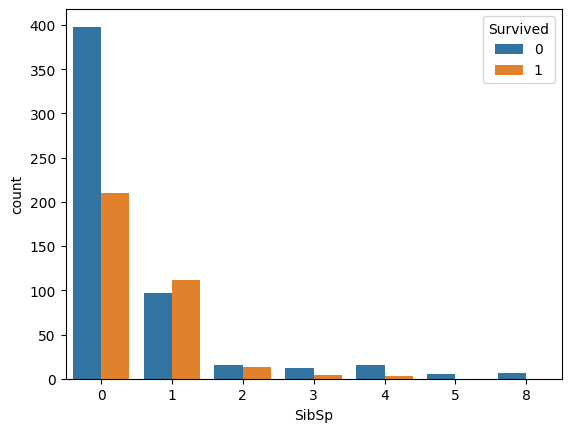

In [81]:
sns.countplot(df,x ='SibSp',hue= 'Survived')

<Axes: xlabel='Parch', ylabel='count'>

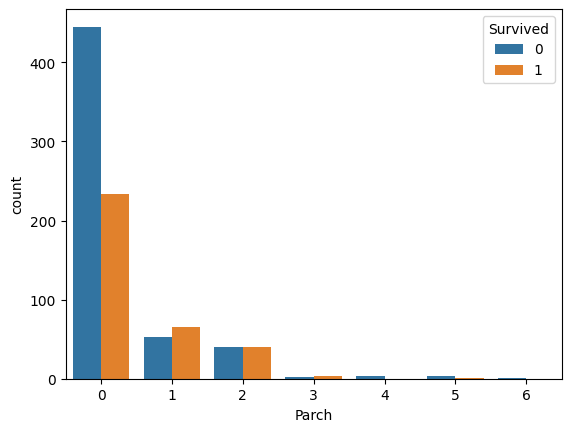

In [82]:
sns.countplot(df,x = 'Parch',hue = 'Survived')

In [83]:
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

<Axes: xlabel='FamilySize', ylabel='count'>

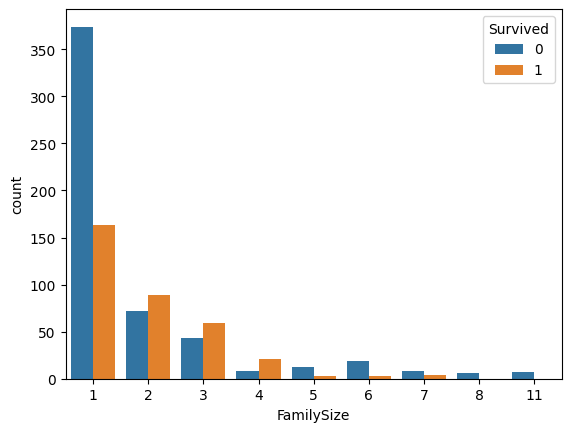

In [84]:
sns.countplot(df,x = 'FamilySize',hue = 'Survived')


In [85]:
df['Name'].sample(20)

,Name
433,"Kallio, Mr. Nikolai Erland"
233,"Asplund, Miss. Lillian Gertrud"
699,"Humblen, Mr. Adolf Mathias Nicolai Olsen"
593,"Bourke, Miss. Mary"
285,"Stankovic, Mr. Ivan"
839,"Marechal, Mr. Pierre"
124,"White, Mr. Percival Wayland"
396,"Olsson, Miss. Elina"
851,"Svensson, Mr. Johan"
716,"Endres, Miss. Caroline Louise"


In [86]:
df['Title'] = df['Name'].str.extract('([A-Za-z]+)\.')

<>:1: SyntaxWarning: invalid escape sequence '\.'
<>:1: SyntaxWarning: invalid escape sequence '\.'
/tmp/ipykernel_1055/3228515422.py:1: SyntaxWarning: invalid escape sequence '\.'
  df['Title'] = df['Name'].str.extract('([A-Za-z]+)\.')


In [87]:
df['Title'] = df['Title'].replace([
    'Lady','Countess','Capt','Col','Don','Dr','Major','Rev','Sir','Jonkheer','Dona'
], 'Rare')

In [88]:
df['Surname'] = df['Name'].str.split(',').str[0]

In [89]:
df['is_high_status'] = df['Title'].isin(['Sir','Lady','Countess']).astype(int)

In [90]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 23 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   PassengerId      891 non-null    int64   
 1   Survived         891 non-null    int64   
 2   Pclass           891 non-null    int64   
 3   Name             891 non-null    object  
 4   Sex              891 non-null    object  
 5   Age              891 non-null    float64 
 6   SibSp            891 non-null    int64   
 7   Parch            891 non-null    int64   
 8   Ticket           891 non-null    object  
 9   Fare             891 non-null    float64 
 10  Cabin            204 non-null    object  
 11  Embarked         889 non-null    object  
 12  Age_group        714 non-null    category
 13  missing_age      891 non-null    int64   
 14  has_cabin        891 non-null    int64   
 15  cabin_female     891 non-null    int64   
 16  ticket_count     891 non-null    int64   
 1

In [91]:
X = df.drop(['PassengerId','Name','Cabin','Survived','Ticket','Cabin'],axis = 1)
y = df['Survived']

In [93]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler,OneHotEncoder

In [94]:
num_cols = X.select_dtypes(include=[int, float]).columns
cat_cols = X.select_dtypes(include = ['object', 'category']).columns

In [96]:
cat_cols

Index(['Sex', 'Embarked', 'Age_group', 'Title', 'Surname'], dtype='object')

In [97]:
for col in cat_cols:
    X[col] = X[col].astype(str)

In [98]:
cat_pipeline = Pipeline([
    ('impute',SimpleImputer(strategy='constant',fill_value='Unknown')),
    ('encoder',OneHotEncoder(sparse_output=False,handle_unknown='ignore'))
])

In [99]:
num_pipeline = Pipeline([
    ('imputer',SimpleImputer(strategy='median')),
    ('scaler',StandardScaler())
])

In [100]:
preprocessing = ColumnTransformer([
    ('cat',cat_pipeline,cat_cols),
    ('num',num_pipeline,num_cols)
])

In [101]:
from sklearn.linear_model import LogisticRegression

In [102]:
pipeline = Pipeline([
    ('preprocessor',preprocessing),
    ('model',LogisticRegression())
])

In [132]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(X,y,stratify= y,test_size=0.2,random_state=42)

In [133]:
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(n_splits=5)

In [104]:
pipeline.fit(x_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(fill_value='Unknown',
                                                                                 strategy='constant')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  Index(['Sex', 'Embarked', 'Age_group', 'Title', 'Surname'], dtype='object')),
                                                 ('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'missing_age', 'has_cabin',
       'cabin_female', 'ticket_count', 'fare_per_person', 'sm_group',
       'FamilySize', 'is_high_status'],
      dtype='object'))])),
                ('model', LogisticRegression())])

In [105]:
y_pred = pipeline.predict(x_test)

In [106]:
from sklearn.metrics import accuracy_score,classification_report


In [107]:
accuracy_score(y_test,y_pred)

0.8212290502793296

In [108]:
from sklearn.ensemble import RandomForestClassifier

In [109]:
rd_pipeline = Pipeline([
    ('pre',preprocessing),
    ('model',RandomForestClassifier())
])

In [110]:
rd_pipeline.fit(x_train,y_train)

Pipeline(steps=[('pre',
                 ColumnTransformer(transformers=[('cat',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(fill_value='Unknown',
                                                                                 strategy='constant')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  Index(['Sex', 'Embarked', 'Age_group', 'Title', 'Surname'], dtype='object')),
                                                 ('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'missing_age', 'has_cabin',
       'cabin_female', 'ticket_count', 'fare_per_person', 'sm_group',
       'FamilySize', 'is_high_status'],
      dtype='object'))])),
                ('model', RandomForestClassifier())])

In [111]:
y_pred = rd_pipeline.predict(x_test)

In [112]:
accuracy_score(y_test,y_pred)

0.8268156424581006

In [131]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(rd_pipeline, X, y, cv=5)
print(scores.mean())

0.8260247316552632


In [114]:

from xgboost import XGBClassifier
xg_pipeline = Pipeline([
    ('pre',preprocessing),
    ('model',XGBClassifier())
])

In [115]:
xg_pipeline.fit(x_train,y_train)
y_pred = xg_pipeline.predict(x_test)


In [116]:
accuracy_score(y_test,y_pred)

0.7821229050279329

In [117]:
param_grid = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [None, 5, 10, 20],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4],
    'model__max_features': ['sqrt', 'log2']
}

In [118]:
from sklearn.model_selection import GridSearchCV

In [135]:
grid = GridSearchCV(
    rd_pipeline,
    param_grid,
    cv = 5,
    scoring = 'accuracy',
    n_jobs = -1
)

In [136]:
grid.fit(x_train,y_train)


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('pre',
                                        ColumnTransformer(transformers=[('cat',
                                                                         Pipeline(steps=[('impute',
                                                                                          SimpleImputer(fill_value='Unknown',
                                                                                                        strategy='constant')),
                                                                                         ('encoder',
                                                                                          OneHotEncoder(handle_unknown='ignore',
                                                                                                        sparse_output=False))]),
                                                                         Index(['Sex', 'Embarked', 'Age_group', 'Title', 'Surname'], dtype='object')),
                                                                        ('num',
                                                                         Pipeline(steps=[('imputer...
       'cabin_female', 'ticket_count', 'fare_per_person', 'sm_group',
       'FamilySize', 'is_high_status'],
      dtype='object'))])),
                                       ('model', RandomForestClassifier())]),
             n_jobs=-1,
             param_grid={'model__max_depth': [None, 5, 10, 20],
                         'model__max_features': ['sqrt', 'log2'],
                         'model__min_samples_leaf': [1, 2, 4],
                         'model__min_samples_split': [2, 5, 10],
                         'model__n_estimators': [100, 200, 300]},
             scoring='accuracy')

In [137]:
print("Best Params:", grid.best_params_)
print("Best CV Score:", grid.best_score_)

best_model = grid.best_estimator_

Best Params: {'model__max_depth': 10, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 100}
Best CV Score: 0.8385304836009061


In [139]:
y_pred = best_model.predict(x_test)
accuracy_score(y_test,y_pred)

0.8324022346368715

In [122]:
from sklearn.svm import SVC

sv_pipeline = Pipeline([
    ('preprocessor', preprocessing),
    ('model', SVC())
])

In [123]:
sv_pipeline.fit(x_train, y_train)

from sklearn.metrics import accuracy_score

y_pred = sv_pipeline.predict(x_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.8156424581005587


In [141]:
!pip install joblib

In [144]:
import joblib
joblib.dump({
    "model": best_model,
    "features": x_train.columns.tolist()
}, "rdmodel.pkl")

['rdmodel.pkl']